In [ ]:
from mads_datasets.base import BaseDatastreamer
from mltrainer.preprocessors import BasePreprocessor
from pathlib import Path
from torch import nn
import torch

from src import datasets

In [20]:
import tomllib

datadir = Path('../data')
configfile = Path("config.toml")

with configfile.open('rb') as f:
    config = tomllib.load(f)
print(config)

{'ptb': 'heart', 'arrhythmia': 'heart_big'}


In [21]:
trainfile = datadir / (config['arrhythmia'] + '_train.parq')
testfile = datadir / (config['arrhythmia'] + '_test.parq')
trainfile, testfile

(PosixPath('../data/heart_big_train.parq'),
 PosixPath('../data/heart_big_test.parq'))

In [22]:
shape = (16, 12)
traindataset = datasets.HeartDataset2D(trainfile, target="target", shape=shape)
testdataset = datasets.HeartDataset2D(testfile, target="target", shape=shape)
traindataset, testdataset

(Heartdataset2D (#87554), Heartdataset2D (#21892))

In [23]:
trainstreamer = BaseDatastreamer(
    traindataset, 
    preprocessor = BasePreprocessor(), 
    batchsize=32
    )

teststreamer = BaseDatastreamer(
    testdataset, 
    preprocessor = BasePreprocessor(), 
    batchsize=32
    )

len(trainstreamer), len(teststreamer)

(2736, 684)

In [24]:
# ============================================
# Experiment 1 - Baseline 2D CNN 
# ============================================

In [25]:
trainloader = trainstreamer.stream()

x, y = next(iter(trainloader))

print(x.shape)
print(y.shape)

torch.Size([32, 1, 16, 12])
torch.Size([32])


2026-07-16 10:16:26.576 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to logs/2D CNN Baseline/run_1/20260716-101626



2D CNN Baseline - run 1


100%|██████████| 547/547 [00:02<00:00, 247.63it/s]
2026-07-16 10:16:30.448 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 0.4500 test 0.3238 metric ['0.9049', '0.9049', '0.5808', '0.9049', '0.5799']
100%|██████████| 547/547 [00:02<00:00, 255.03it/s]
2026-07-16 10:16:34.356 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.2865 test 0.2699 metric ['0.9295', '0.9295', '0.6969', '0.9295', '0.6988']
100%|██████████| 547/547 [00:02<00:00, 250.52it/s]
2026-07-16 10:16:38.218 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.2555 test 0.2480 metric ['0.9338', '0.9338', '0.7187', '0.9338', '0.7191']
100%|██████████| 547/547 [00:02<00:00, 222.01it/s]
2026-07-16 10:16:42.305 | INFO     | mltrainer.trainer:report:209 - Epoch 3 train 0.2334 test 0.2236 metric ['0.9432', '0.9432', '0.7350', '0.9432', '0.7375']
100%|██████████| 547/547 [00:02<00:00, 265.72it/s]
2026-07-16 10:16:46.000 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.2045 test 0.2140 metric [

Accuracy: 0.946
Recall: [0.993 0.304 0.751 0.303 0.879]

2D CNN Baseline - run 2


100%|██████████| 547/547 [00:02<00:00, 215.72it/s]
2026-07-16 10:16:51.134 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 0.4601 test 0.3312 metric ['0.9010', '0.9010', '0.5826', '0.9010', '0.5825']
100%|██████████| 547/547 [00:02<00:00, 265.48it/s]
2026-07-16 10:16:54.845 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.2888 test 0.2792 metric ['0.9278', '0.9278', '0.7132', '0.9278', '0.7038']
100%|██████████| 547/547 [00:02<00:00, 267.10it/s]
2026-07-16 10:16:58.557 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.2519 test 0.2185 metric ['0.9409', '0.9409', '0.7178', '0.9409', '0.7266']
100%|██████████| 547/547 [00:02<00:00, 243.16it/s]
2026-07-16 10:17:02.519 | INFO     | mltrainer.trainer:report:209 - Epoch 3 train 0.2194 test 0.2291 metric ['0.9432', '0.9432', '0.7409', '0.9432', '0.7413']
100%|██████████| 547/547 [00:02<00:00, 252.19it/s]
2026-07-16 10:17:06.317 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.2185 test 0.2263 metric [

Accuracy: 0.947
Recall: [0.992 0.379 0.769 0.16  0.878]

2D CNN Baseline - run 3


100%|██████████| 547/547 [00:02<00:00, 254.94it/s]
2026-07-16 10:17:11.153 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 0.4546 test 0.3543 metric ['0.9095', '0.9095', '0.6527', '0.9095', '0.6783']
100%|██████████| 547/547 [00:02<00:00, 241.37it/s]
2026-07-16 10:17:15.118 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.2884 test 0.2642 metric ['0.9338', '0.9338', '0.7083', '0.9338', '0.7246']
100%|██████████| 547/547 [00:02<00:00, 250.73it/s]
2026-07-16 10:17:18.984 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.2460 test 0.2565 metric ['0.9350', '0.9350', '0.6963', '0.9350', '0.7030']
100%|██████████| 547/547 [00:02<00:00, 249.06it/s]
2026-07-16 10:17:22.853 | INFO     | mltrainer.trainer:report:209 - Epoch 3 train 0.2350 test 0.2351 metric ['0.9389', '0.9389', '0.7297', '0.9389', '0.7261']
100%|██████████| 547/547 [00:02<00:00, 261.82it/s]
2026-07-16 10:17:26.536 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.2099 test 0.2224 metric [

Accuracy: 0.942
Recall: [0.995 0.166 0.732 0.118 0.873]


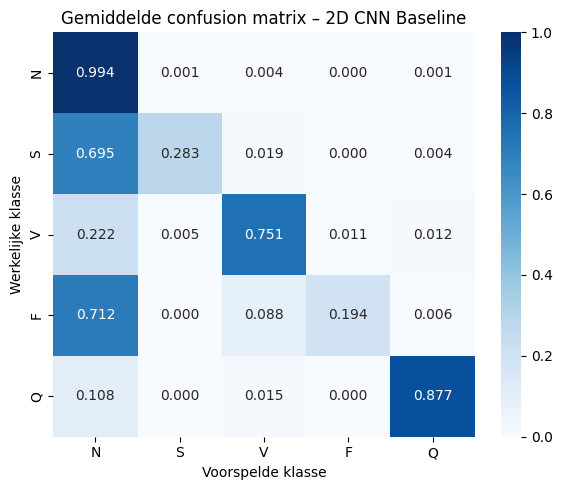

In [26]:
from src.helpers import run_experiment
from src.networks import CNN2D


run_experiment(
    model_function=lambda: CNN2D(
        num_classes=5,
        filters=16,
        matrixshape=(16, 12),
    ),
    experiment_name="2D CNN Baseline",
    trainstreamer=trainstreamer,
    teststreamer=teststreamer,
    loss_fn=nn.CrossEntropyLoss(),
    class_weights=True,
    parallel=False,
    runs=3,
    epochs=5,
    filename="results/results.csv",
)

In [27]:
# ============================================
# Experiment 2 - 2D CNN met class weights
# ============================================

In [28]:
# Weights berekenen

class_counts = torch.bincount(traindataset.y)

class_weights = class_counts.sum() / (
    len(class_counts) * class_counts.float()
)

classes = ["N", "S", "V", "F", "Q"]

for cls, count, weight in zip(classes, class_counts, class_weights):
    print(f"{cls}: count={count}, weight={weight:.3f}")

N: count=72471, weight=0.242
S: count=2223, weight=7.877
V: count=5788, weight=3.025
F: count=641, weight=27.318
Q: count=6431, weight=2.723


2026-07-16 10:17:28.346 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to logs/2D CNN Weighted/run_1/20260716-101728



2D CNN Weighted - run 1


100%|██████████| 547/547 [00:02<00:00, 264.93it/s]
2026-07-16 10:17:31.995 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 1.0383 test 0.8880 metric ['0.7135', '0.7135', '0.4466', '0.7135', '0.7160']
100%|██████████| 547/547 [00:01<00:00, 279.02it/s]
2026-07-16 10:17:35.508 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.7951 test 0.7145 metric ['0.7429', '0.7429', '0.4970', '0.7429', '0.7347']
100%|██████████| 547/547 [00:02<00:00, 265.84it/s]
2026-07-16 10:17:39.186 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.6671 test 0.6403 metric ['0.6620', '0.6620', '0.4642', '0.6620', '0.7680']
100%|██████████| 547/547 [00:02<00:00, 256.62it/s]
2026-07-16 10:17:42.957 | INFO     | mltrainer.trainer:report:209 - Epoch 3 train 0.6364 test 0.6209 metric ['0.8003', '0.8003', '0.5373', '0.8003', '0.7935']
100%|██████████| 547/547 [00:02<00:00, 250.16it/s]
2026-07-16 10:17:46.713 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.5911 test 0.5798 metric [

Accuracy: 0.834
Recall: [0.839 0.609 0.793 0.826 0.896]

2D CNN Weighted - run 2


100%|██████████| 547/547 [00:02<00:00, 265.88it/s]
2026-07-16 10:17:51.361 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 1.0184 test 0.7581 metric ['0.7006', '0.7006', '0.4407', '0.7006', '0.7051']
100%|██████████| 547/547 [00:02<00:00, 272.59it/s]
2026-07-16 10:17:54.989 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.7409 test 0.6900 metric ['0.7148', '0.7148', '0.4707', '0.7148', '0.7503']
100%|██████████| 547/547 [00:02<00:00, 271.34it/s]
2026-07-16 10:17:58.656 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.6510 test 0.6627 metric ['0.7663', '0.7663', '0.5064', '0.7663', '0.7714']
100%|██████████| 547/547 [00:02<00:00, 221.82it/s]
2026-07-16 10:18:02.684 | INFO     | mltrainer.trainer:report:209 - Epoch 3 train 0.6055 test 0.5779 metric ['0.8249', '0.8249', '0.5506', '0.8249', '0.8040']
100%|██████████| 547/547 [00:02<00:00, 269.31it/s]
2026-07-16 10:18:06.295 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.5716 test 0.5501 metric [

Accuracy: 0.858
Recall: [0.864 0.569 0.844 0.765 0.906]

2D CNN Weighted - run 3


100%|██████████| 547/547 [00:01<00:00, 275.83it/s]
2026-07-16 10:18:10.955 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 1.0276 test 0.8247 metric ['0.7224', '0.7224', '0.4800', '0.7224', '0.7490']
100%|██████████| 547/547 [00:02<00:00, 211.36it/s]
2026-07-16 10:18:15.141 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.7251 test 0.6536 metric ['0.7911', '0.7911', '0.5268', '0.7911', '0.7882']
100%|██████████| 547/547 [00:02<00:00, 263.32it/s]
2026-07-16 10:18:18.886 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.6310 test 0.6214 metric ['0.7881', '0.7881', '0.5203', '0.7881', '0.7702']
100%|██████████| 547/547 [00:02<00:00, 256.92it/s]
2026-07-16 10:18:22.828 | INFO     | mltrainer.trainer:report:209 - Epoch 3 train 0.5991 test 0.6139 metric ['0.8791', '0.8791', '0.6106', '0.8791', '0.7969']
100%|██████████| 547/547 [00:03<00:00, 165.57it/s]
2026-07-16 10:18:27.967 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.6044 test 0.5349 metric [

Accuracy: 0.784
Recall: [0.776 0.726 0.776 0.776 0.909]


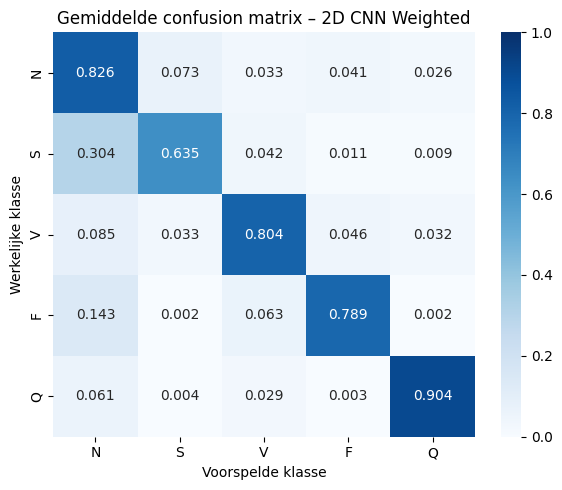

In [29]:
run_experiment(
    model_function=lambda: CNN2D(
        num_classes=5,
        filters=16,
        matrixshape=(16, 12),
    ),
    experiment_name="2D CNN Weighted",
    trainstreamer=trainstreamer,
    teststreamer=teststreamer,
    loss_fn=nn.CrossEntropyLoss(
        weight=class_weights,
    ),
    class_weights=True,
    parallel=False,
    runs=3,
    epochs=5,
    filename="results/results.csv",
)

In [30]:
# =============================================================
# Experiment 3 - 2D CNN met class weights en paralelle kernels
# =============================================================

2026-07-16 10:18:29.806 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to logs/Parallelle 2D CNN/run_1/20260716-101829



Parallelle 2D CNN - run 1


100%|██████████| 547/547 [00:05<00:00, 95.13it/s]
2026-07-16 10:18:38.490 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 0.9325 test 0.7112 metric ['0.8559', '0.8559', '0.5712', '0.8559', '0.7859']
100%|██████████| 547/547 [00:03<00:00, 145.83it/s]
2026-07-16 10:18:44.014 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.6786 test 0.6481 metric ['0.8886', '0.8886', '0.6512', '0.8886', '0.8007']
100%|██████████| 547/547 [00:03<00:00, 154.56it/s]
2026-07-16 10:18:49.314 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.5802 test 0.5734 metric ['0.8380', '0.8380', '0.5847', '0.8380', '0.8061']
100%|██████████| 547/547 [00:04<00:00, 136.71it/s]
2026-07-16 10:18:55.411 | INFO     | mltrainer.trainer:report:209 - Epoch 3 train 0.5274 test 0.4953 metric ['0.8614', '0.8614', '0.6043', '0.8614', '0.8340']
100%|██████████| 547/547 [00:04<00:00, 134.52it/s]
2026-07-16 10:19:01.245 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.4880 test 0.4728 metric ['

Accuracy: 0.883
Recall: [0.892 0.649 0.818 0.832 0.931]

Parallelle 2D CNN - run 2


100%|██████████| 547/547 [00:03<00:00, 151.91it/s]
2026-07-16 10:19:09.404 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 0.9182 test 0.6872 metric ['0.6193', '0.6193', '0.4236', '0.6193', '0.7421']
100%|██████████| 547/547 [00:05<00:00, 105.59it/s]
2026-07-16 10:19:16.438 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.6321 test 0.6378 metric ['0.8720', '0.8720', '0.6006', '0.8720', '0.8009']
100%|██████████| 547/547 [00:04<00:00, 112.30it/s]
2026-07-16 10:19:23.622 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.5638 test 0.6371 metric ['0.7456', '0.7456', '0.5500', '0.7456', '0.7748']
100%|██████████| 547/547 [00:05<00:00, 103.48it/s]
2026-07-16 10:19:30.702 | INFO     | mltrainer.trainer:report:209 - Epoch 3 train 0.5804 test 0.4734 metric ['0.8373', '0.8373', '0.6009', '0.8373', '0.8431']
100%|██████████| 547/547 [00:05<00:00, 97.31it/s] 
2026-07-16 10:19:38.382 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.5122 test 0.5352 metric [

Accuracy: 0.880
Recall: [0.887 0.624 0.875 0.787 0.91 ]

Parallelle 2D CNN - run 3


100%|██████████| 547/547 [00:04<00:00, 109.87it/s]
2026-07-16 10:19:47.874 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 0.9437 test 0.6919 metric ['0.7452', '0.7452', '0.4844', '0.7452', '0.7569']
100%|██████████| 547/547 [00:05<00:00, 104.30it/s]
2026-07-16 10:19:55.301 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.6702 test 0.6414 metric ['0.6636', '0.6636', '0.4903', '0.6636', '0.7761']
100%|██████████| 547/547 [00:05<00:00, 104.10it/s]
2026-07-16 10:20:02.751 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.5993 test 0.5430 metric ['0.7555', '0.7555', '0.5354', '0.7555', '0.7929']
100%|██████████| 547/547 [00:05<00:00, 103.20it/s]
2026-07-16 10:20:10.053 | INFO     | mltrainer.trainer:report:209 - Epoch 3 train 0.5317 test 0.6229 metric ['0.8182', '0.8182', '0.5658', '0.8182', '0.8075']
100%|██████████| 547/547 [00:05<00:00, 101.49it/s]
2026-07-16 10:20:18.003 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.4875 test 0.4879 metric [

Accuracy: 0.784
Recall: [0.767 0.767 0.845 0.825 0.926]


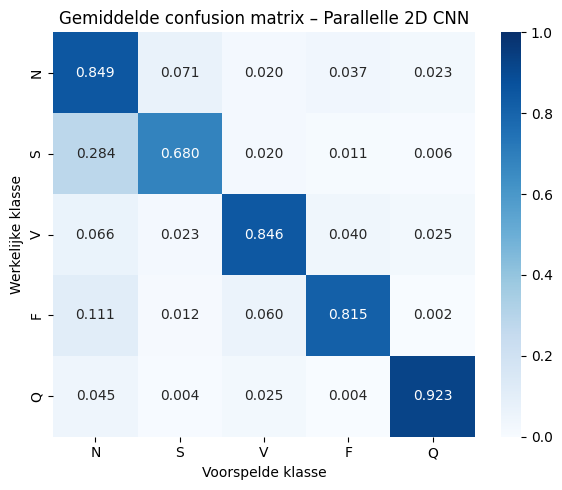

In [31]:
from src.networks import ParallelCNN2D


run_experiment(
    model_function=lambda: ParallelCNN2D(
        num_classes=5,
        filters=16,
        matrixshape=(16, 12),
    ),
    experiment_name="Parallelle 2D CNN",
    trainstreamer=trainstreamer,
    teststreamer=teststreamer,
    loss_fn=nn.CrossEntropyLoss(
        weight=class_weights,
    ),
    class_weights=True,
    parallel=True,
    runs=3,
    epochs=5,
    filename="results/results.csv",
)